El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente, ademas incluye Batch Normalization y Dropout

Importación de librerías

In [2]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones

In [3]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'


# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [9]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [5]:
#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, Concatenate, BatchNormalization, Dropout)
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.callbacks import EarlyStopping

# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada
inputs = Input(shape=X.shape[1:])

# Bloque 1
x1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
x2 = Conv2D(16, (5, 5), activation='relu', padding='same')(inputs)
x = Concatenate()([x1, x2])
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Bloque 2
x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x2 = Conv2D(32, (5, 5), activation='relu', padding='same')(x)
x = Concatenate()([x1, x2])
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Bloque 3
x1 = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x2 = Conv2D(64, (5, 5), activation='relu', padding='same')(x)
x = Concatenate()([x1, x2])
x = BatchNormalization()(x)
x = Dropout(0.3)(x)  # un poco más de dropout en capa más profunda

# Bloque 4
x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x2 = Conv2D(32, (5, 5), activation='relu', padding='same')(x)
x = Concatenate()([x1, x2])
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Bloque 5
x1 = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x2 = Conv2D(16, (5, 5), activation='relu', padding='same')(x)
x = Concatenate()([x1, x2])
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Capa de salida
outputs = Conv2D(1, (3, 3), activation='linear', padding='same')(x)

# Definición del modelo
model6 = Model(inputs, outputs)

# Compilación
model6.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model6.summary()

# Entrenamiento con EarlyStopping
print("Iniciando entrenamiento...")

checkpoint = ModelCheckpoint(
    filepath="mejor_modelo.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history6= model6.fit(
    X, y,
    epochs=15,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Prueba completada!")
print(f"Pérdida final: {history6.history['loss'][-1]:.4f}")



Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 480, 480,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 480,  │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 480, 480,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 480, 480,  │        128 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 480, 480,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 480,  │      9,248 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 480, 480,  │     25,632 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 480, 480,  │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 480, 480,  │        256 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 480, 480,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 480, 480,  │     36,928 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 480, 480,  │    102,464 │ dropout_1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 480, 480,  │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 480, 480,  │        512 │ concatenate_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 480, 480,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 480, 480,  │     36,896 │ dropout_2[0][0] 

 Total params: 350,593 (1.34 MB)

 Trainable params: 349,953 (1.33 MB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 646s 7s/step - loss: 0.0107 - mean_absolute_percentage_error: 1251.2007 - root_mean_squared_error: 0.1035
Epoch 12/15
Epoch 12/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.0103 - mean_absolute_percentage_error: 1180.7738 - root_mean_squared_error: 0.1015

93/93 ━━━━━━━━━━━━━━━━━━━━ 645s 7s/step - loss: 0.0104 - mean_absolute_percentage_error: 1252.2498 - root_mean_squared_error: 0.1018
Epoch 13/15
Epoch 13/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.0100 - mean_absolute_percentage_error: 1178.9338 - root_mean_squared_error: 0.1001

93/93 ━━━━━━━━━━━━━━━━━━━━ 645s 7s/step - loss: 0.0101 - mean_absolute_percentage_error: 1240.0786 - root_mean_squared_error: 0.1005
Epoch 14/15
Epoch 14/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.0098 - mean_absolute_percentage_error: 1182.9758 - root_mean_squared_error: 0.0991

93/93 ━━━━━━━━━━━━━━━━━━━━ 646s 7s/step - loss: 0.0099 - mean_absolute_percentage_error: 1244.1542 - root_mean_squared_error: 0.0996
Epoch 15/15
Epoch 15/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 0.0097 - mean_absolute_percentage_error: 1142.3085 - root_mean_squared_error: 0.0983

93/93 ━━━━━━━━━━━━━━━━━━━━ 646s 7s/step - loss: 0.0098 - mean_absolute_percentage_error: 1219.4617 - root_mean_squared_error: 0.0988
¡Prueba completada!
Pérdida final: 0.0098
¡Prueba completada!
Pérdida final: 0.0098


Valores de las metricas

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model6.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - loss: 0.0085 - mean_absolute_percentage_error: 1323.9857 - root_mean_squared_error: 0.0923
24/24 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - loss: 0.0085 - mean_absolute_percentage_error: 1323.9857 - root_mean_squared_error: 0.0923
Pérdida (MSE): 0.0085
RMSE: 0.0923
MAPE: 1323.9857
Pérdida (MSE): 0.0085
RMSE: 0.0923
MAPE: 1323.9857


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 107s 4s/step


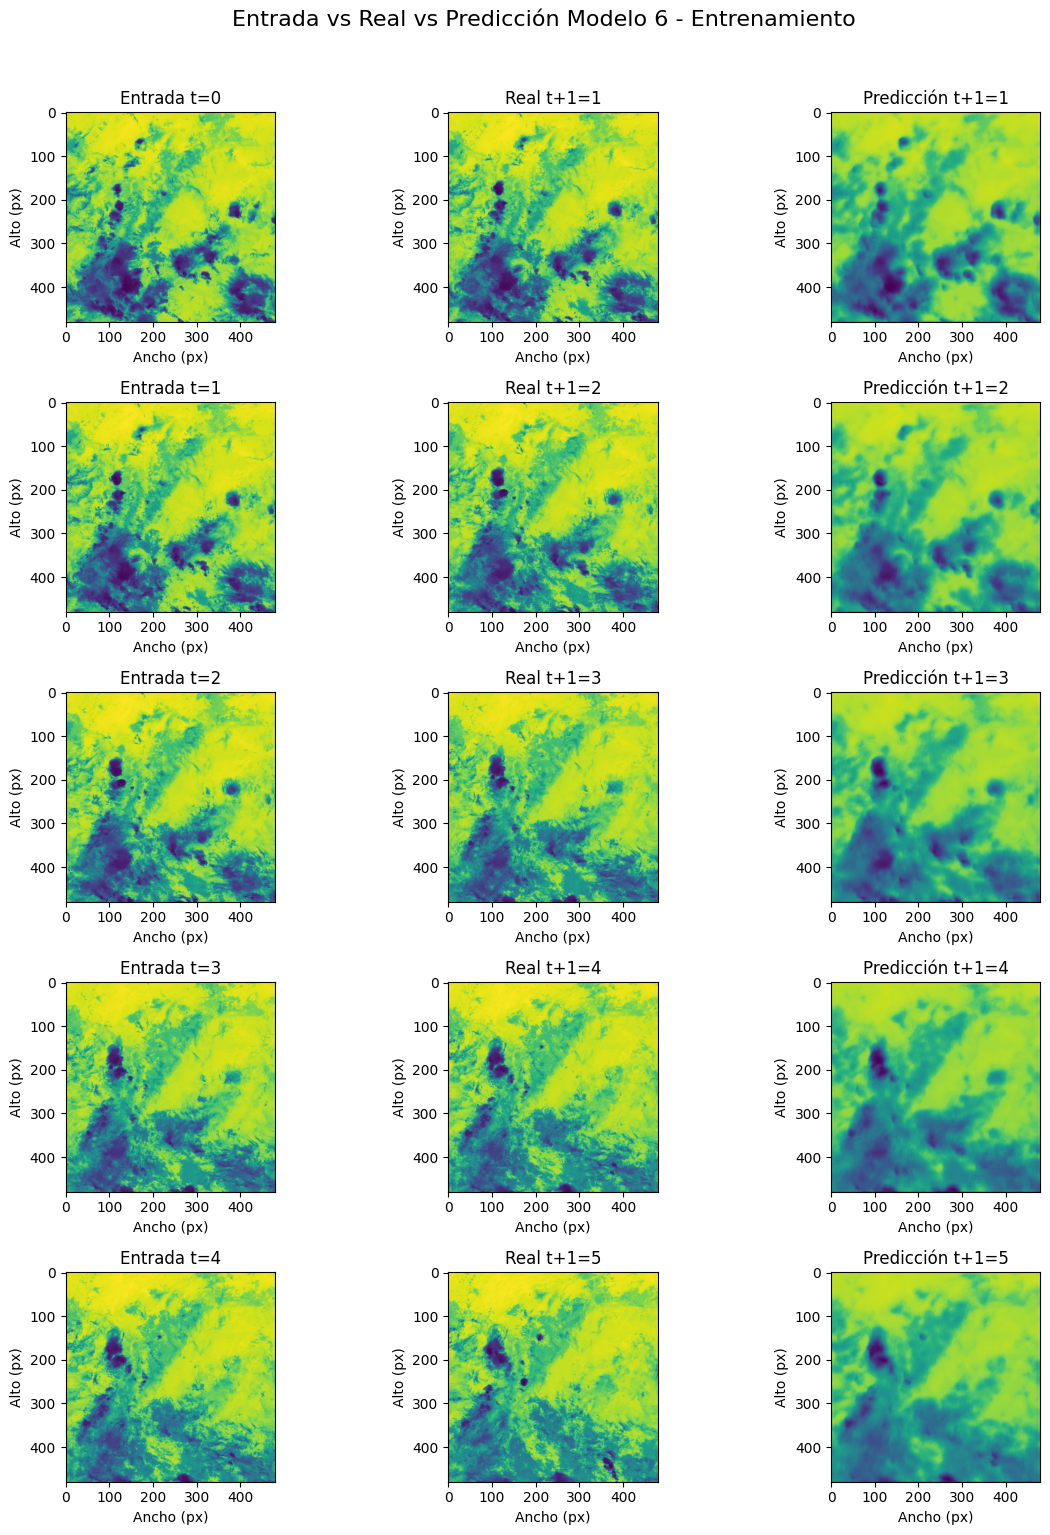

In [10]:
y_pred6 = model6.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred6, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 6 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 110s 5s/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 110s 5s/step


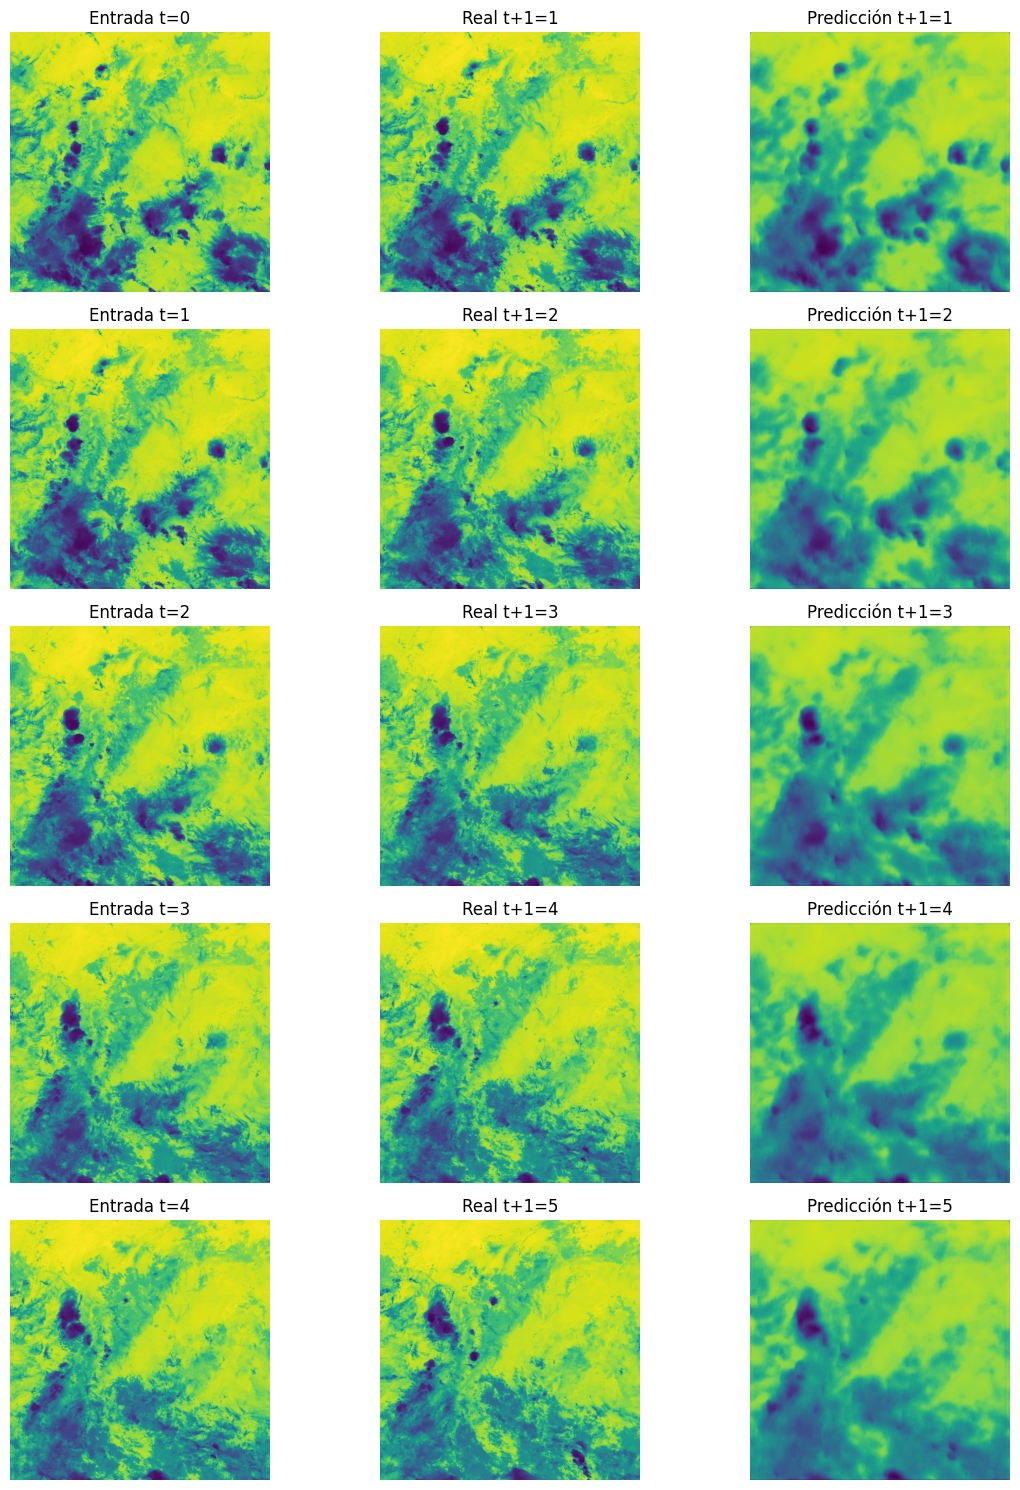

In [11]:
y_pred6 = model6.predict(X)  # Genera las predicciones

# Selecciona el número de ejemplos a mostrar
n = 5

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred6[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

Validación

In [12]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [13]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model6.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.0170 - mean_absolute_percentage_error: 1186.7498 - root_mean_squared_error: 0.1302
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 0.0170 - mean_absolute_percentage_error: 1186.7498 - root_mean_squared_error: 0.1302
Pérdida (MSE): 0.0170
RMSE: 0.1302
MAPE: 1186.7498
Pérdida (MSE): 0.0170
RMSE: 0.1302
MAPE: 1186.7498


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step


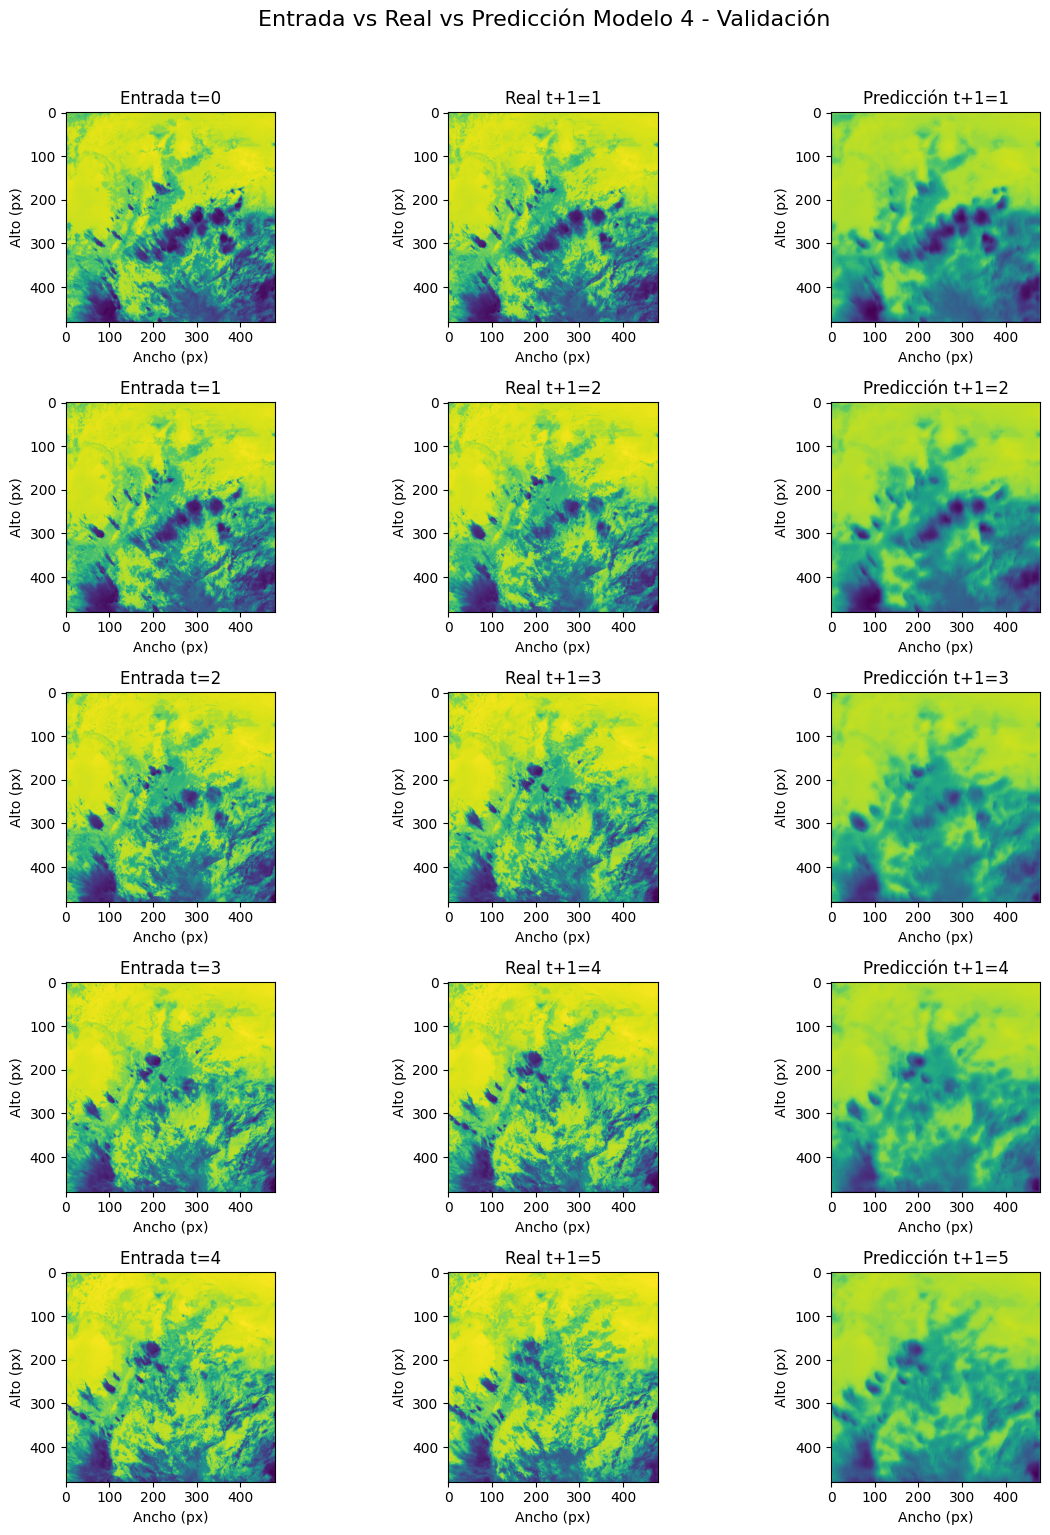

In [14]:
y_pred6_val = model6.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred6_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 6 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)